c:\Users\yassi\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


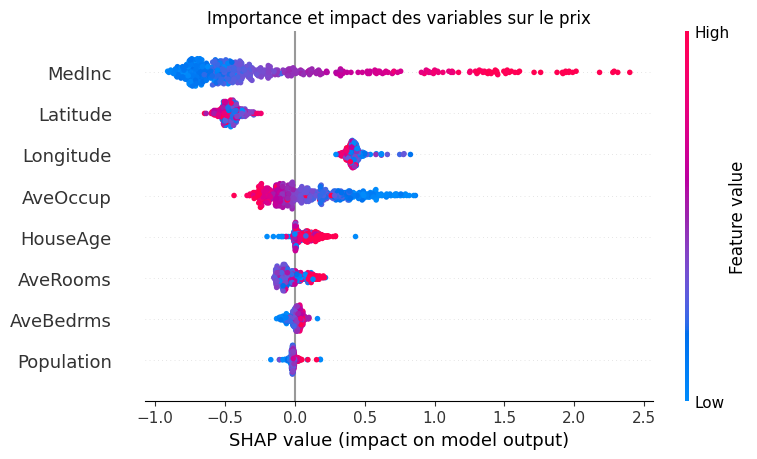

In [1]:
import joblib
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

model = joblib.load('../models/housing_model.pkl')
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)

xgboost_model = model.named_steps['regressor']
X_transformed = model.named_steps['scaler'].transform(X)
X_transformed_df = pd.DataFrame(X_transformed, columns=data.feature_names)

explainer = shap.Explainer(xgboost_model)
shap_values = explainer(X_transformed_df.iloc[:500])

plt.title("Importance et impact des variables sur le prix")
shap.summary_plot(shap_values, X_transformed_df.iloc[:500])